[Universe] Wikipedia unavailable (`Import lxml` failed.  Use pip or conda to install the lxml package.). Using curated top-100 large-cap fallback.
[Data] Downloading prices 2021-12-01 → 2026-05-16 …


$MMC: possibly delisted; no timezone found

1 Failed download:
['MMC']: possibly delisted; no timezone found


  … batch 1/2 done
  … batch 2/2 done
[Data] Price matrix: 1118 days × 105 stocks
[Signal] Computing 12-1 month momentum …
[Portfolio] Building top-decile weights …

── Performance Summary ──────────────────────────
Total Return             169.16%
Annualised Return         34.35%
Annualised Volatility     26.03%
Sharpe Ratio                1.32
Max Drawdown             -23.91%
Calmar Ratio                1.44
Win Rate (daily)          53.61%
Observations                 845

── Top-Decile Constituents as of 2026-05-15 (10 stocks) ──
AMAT, AMD, C, CAT, FDX, GOOGL, INTC, MU, KLAC, LRCX


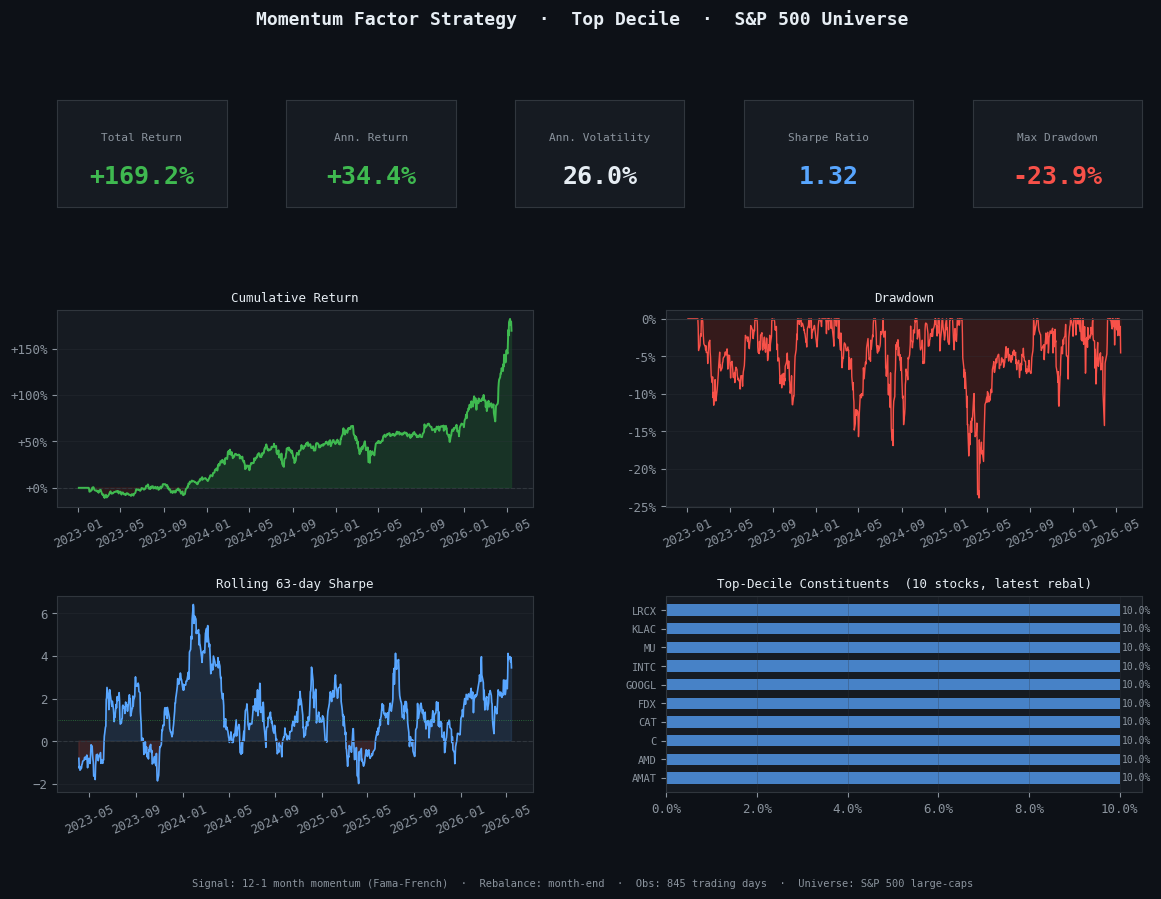

In [3]:
"""
Momentum Factor Quant Strategy
================================
Universe  : S&P 500 large-cap stocks
Signal    : 12-1 month total return (Fama-French style — skip last month
            to avoid short-term reversal contamination)
Portfolio : Long top-decile (D10) by momentum score, equally weighted
Output    : Daily boolean/weight vector of top-decile constituents,
            plus portfolio returns and summary statistics.

Usage:
    python momentum_strategy.py [--start YYYY-MM-DD] [--end YYYY-MM-DD]
                                [--decile 10] [--output results.csv]
"""

import argparse
import warnings
from datetime import datetime

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import yfinance as yf

warnings.filterwarnings("ignore")


# ── 1. Universe ───────────────────────────────────────────────────────────────

def get_sp500_tickers() -> list[str]:
    """
    Scrape current S&P 500 constituents from Wikipedia.
    Falls back to a curated top-100 large-cap list if Wikipedia is blocked.
    """
    # Fallback curated large-cap universe (top ~106 S&P 500 by market cap)
    FALLBACK = [
        'AAPL','MSFT','NVDA','AMZN','GOOGL','META','TSLA','BRK-B','AVGO','JPM',
        'LLY','UNH','V','XOM','MA','JNJ','COST','PG','ORCL','HD','WMT','ABBV',
        'BAC','KO','MRK','CVX','NFLX','AMD','CRM','TMO','PEP','ADBE','WFC','ACN',
        'LIN','CSCO','MCD','ABT','DHR','TXN','PM','CAT','NEE','NKE','IBM','INTC',
        'UNP','RTX','AMGN','HON','VZ','LOW','QCOM','SPGI','GS','AMAT','ELV','MDT',
        'PLD','MS','SCHW','SYK','BMY','BLK','AXP','TJX','ISRG','GILD','ADI','C',
        'MMC','DE','EOG','MO','CI','USB','SO','REGN','PYPL','SLB','ZTS','CME',
        'DUK','CL','ITW','GE','ICE','NOC','BSX','ETN','AON','HUM','MU','MCO',
        'TGT','FCX','APD','PSA','HCA','FDX','MMM','PNC','ECL','KLAC','NSC','LRCX'
    ]
    try:
        import urllib.request
        req = urllib.request.Request(
            "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies",
            headers={"User-Agent": "Mozilla/5.0 (compatible; research-bot/1.0)"}
        )
        html = urllib.request.urlopen(req, timeout=10).read()
        tables = pd.read_html(html)
        tickers = (
            tables[0]["Symbol"]
            .str.replace(".", "-", regex=False)
            .tolist()
        )
        print(f"[Universe] {len(tickers)} S&P 500 tickers loaded from Wikipedia.")
        return tickers
    except Exception as e:
        print(f"[Universe] Wikipedia unavailable ({e}). Using curated top-100 large-cap fallback.")
        return FALLBACK


# ── 2. Data Download ──────────────────────────────────────────────────────────

def download_prices(
    tickers: list[str],
    start: str,
    end: str,
    batch: int = 100,
) -> pd.DataFrame:
    """
    Download adjusted closing prices in batches.
    Returns a DataFrame: index=Date, columns=Ticker.
    """
    print(f"[Data] Downloading prices {start} → {end} …")
    frames = []
    for i in range(0, len(tickers), batch):
        chunk = tickers[i : i + batch]
        raw = yf.download(
            chunk,
            start=start,
            end=end,
            auto_adjust=True,
            progress=False,
            threads=True,
        )
        # yfinance returns multi-level columns when >1 ticker
        if isinstance(raw.columns, pd.MultiIndex):
            close = raw["Close"]
        else:
            close = raw[["Close"]]
            close.columns = chunk
        frames.append(close)
        print(f"  … batch {i//batch + 1}/{(len(tickers)-1)//batch + 1} done")

    prices = pd.concat(frames, axis=1)
    prices.index = pd.to_datetime(prices.index)
    # Drop tickers with >20% missing data
    threshold = 0.80
    prices = prices.loc[:, prices.notna().mean() >= threshold]
    print(f"[Data] Price matrix: {prices.shape[0]} days × {prices.shape[1]} stocks")
    return prices


# ── 3. Momentum Signal ────────────────────────────────────────────────────────

def compute_momentum(
    prices: pd.DataFrame,
    lookback_months: int = 12,
    skip_months: int = 1,
) -> pd.DataFrame:
    """
    Compute cross-sectional momentum for each stock on each rebalance date.

    Signal = total return from (T - lookback_months) to (T - skip_months).
    Standard Fama-French: lookback=12, skip=1  →  11-month window ending 1m ago.

    Returns DataFrame of same shape as prices with momentum scores.
    """
    # Convert month offsets to approximate trading days
    lookback_days = lookback_months * 21
    skip_days     = skip_months    * 21

    # Price at signal end  (T - skip)
    price_end   = prices.shift(skip_days)
    # Price at signal start (T - lookback)
    price_start = prices.shift(lookback_days)

    momentum = price_end / price_start - 1          # total return
    return momentum


# ── 4. Portfolio Construction ─────────────────────────────────────────────────

def build_top_decile_weights(
    momentum: pd.DataFrame,
    rebal_freq: str = "ME",      # month-end rebalance
    top_decile: int = 10,
) -> pd.DataFrame:
    """
    On each rebalance date, rank stocks by momentum and assign equal weight
    to the top decile.  Weights are held constant until the next rebalance.

    Returns a daily weight matrix (same shape as momentum).
    """
    # Rebalance dates = month-end business days present in index
    rebal_dates = momentum.resample(rebal_freq).last().index
    rebal_dates = rebal_dates[rebal_dates.isin(momentum.index)]

    weights_on_rebal = []

    for date in rebal_dates:
        scores = momentum.loc[date].dropna()
        if len(scores) < 20:          # not enough stocks — skip
            continue

        cutoff = np.percentile(scores, 100 - top_decile)   # top-decile threshold
        selected = (scores >= cutoff).astype(float)

        # Break ties: ensure exactly top_decile% are selected
        n_target = max(1, round(len(scores) * top_decile / 100))
        # Sort and take the top n_target
        top_stocks = scores.nlargest(n_target).index
        selected   = pd.Series(0.0, index=momentum.columns)
        selected[top_stocks] = 1.0 / len(top_stocks)       # equal weight

        weights_on_rebal.append(pd.Series(selected, name=date))

    rebal_df = pd.DataFrame(weights_on_rebal)          # rebal dates × stocks
    # Forward-fill to daily frequency
    weights_daily = (
        rebal_df
        .reindex(momentum.index)
        .ffill()
        .fillna(0.0)
    )
    return weights_daily


# ── 5. Performance ────────────────────────────────────────────────────────────

def compute_portfolio_returns(
    prices: pd.DataFrame,
    weights: pd.DataFrame,
) -> pd.Series:
    """Daily portfolio returns given daily weight matrix."""
    returns = prices.pct_change()
    port_ret = (weights.shift(1) * returns).sum(axis=1)   # lag weights 1 day
    return port_ret.rename("Momentum_D10")


def performance_summary(returns: pd.Series) -> pd.DataFrame:
    """Annualised statistics."""
    ann = 252
    total_ret  = (1 + returns).prod() - 1
    ann_ret    = (1 + total_ret) ** (ann / len(returns)) - 1
    ann_vol    = returns.std() * np.sqrt(ann)
    sharpe     = ann_ret / ann_vol if ann_vol else np.nan
    cum        = (1 + returns).cumprod()
    drawdown   = cum / cum.cummax() - 1
    max_dd     = drawdown.min()
    calmar     = ann_ret / abs(max_dd) if max_dd else np.nan
    win_rate   = (returns > 0).mean()

    stats = {
        "Total Return"          : f"{total_ret:.2%}",
        "Annualised Return"     : f"{ann_ret:.2%}",
        "Annualised Volatility" : f"{ann_vol:.2%}",
        "Sharpe Ratio"          : f"{sharpe:.2f}",
        "Max Drawdown"          : f"{max_dd:.2%}",
        "Calmar Ratio"          : f"{calmar:.2f}",
        "Win Rate (daily)"      : f"{win_rate:.2%}",
        "Observations"          : len(returns),
    }
    return pd.Series(stats, name="Momentum D10")


# ── 6. Dashboard Plot ─────────────────────────────────────────────────────────

def plot_dashboard(
    port_returns: pd.Series,
    weights: pd.DataFrame,
    summary: pd.Series,
) -> None:
    """
    Render a 4-panel dashboard matching the web UI:
      [row 1]  5 stat cards (total return, ann return, vol, sharpe, max DD)
      [row 2]  Cumulative return curve  |  Drawdown area chart
      [row 3]  Rolling 63-day Sharpe    |  Top-decile constituents bar
    """
    r = port_returns.dropna()
    cum    = (1 + r).cumprod()
    dd     = cum / cum.cummax() - 1
    roll_sharpe = r.rolling(63).mean() / r.rolling(63).std() * (252 ** 0.5)

    # ── parse summary values ──────────────────────────────────────────────────
    def pct(s):   return float(s.strip('%')) / 100
    def flt(s):   return float(s)

    total_ret = pct(summary["Total Return"])
    ann_ret   = pct(summary["Annualised Return"])
    ann_vol   = pct(summary["Annualised Volatility"])
    sharpe    = flt(summary["Sharpe Ratio"])
    max_dd    = pct(summary["Max Drawdown"])

    # ── colour scheme ─────────────────────────────────────────────────────────
    BG        = "#0d1117"
    PANEL     = "#161b22"
    BORDER    = "#30363d"
    GREEN     = "#3fb950"
    GREEN_F   = "#1a4429"
    RED       = "#f85149"
    RED_F     = "#3d1a1a"
    MUTED     = "#8b949e"
    TEXT      = "#e6edf3"
    ACCENT    = "#58a6ff"

    plt.rcParams.update({
        "figure.facecolor":  BG,
        "axes.facecolor":    PANEL,
        "axes.edgecolor":    BORDER,
        "axes.labelcolor":   MUTED,
        "xtick.color":       MUTED,
        "ytick.color":       MUTED,
        "text.color":        TEXT,
        "grid.color":        BORDER,
        "grid.linewidth":    0.5,
        "font.family":       "monospace",
        "font.size":         9,
    })

    fig = plt.figure(figsize=(14, 9), facecolor=BG)
    fig.suptitle(
        "Momentum Factor Strategy  ·  Top Decile  ·  S&P 500 Universe",
        fontsize=13, fontweight="bold", color=TEXT, y=0.98,
    )

    # ── layout: stat row + 2×2 chart grid ────────────────────────────────────
    outer = gridspec.GridSpec(
        2, 1, figure=fig,
        height_ratios=[1, 4.5],
        hspace=0.35,
    )
    stat_gs   = gridspec.GridSpecFromSubplotSpec(1, 5, subplot_spec=outer[0], wspace=0.35)
    chart_gs  = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=outer[1], hspace=0.45, wspace=0.28)

    # ── helper: stat card ────────────────────────────────────────────────────
    def stat_card(ax, label, value_str, color=TEXT):
        ax.set_facecolor(PANEL)
        for spine in ax.spines.values():
            spine.set_edgecolor(BORDER)
            spine.set_linewidth(0.8)
        ax.set_xticks([]); ax.set_yticks([])
        ax.text(0.5, 0.65, label,  transform=ax.transAxes,
                ha="center", va="center", fontsize=8, color=MUTED)
        ax.text(0.5, 0.28, value_str, transform=ax.transAxes,
                ha="center", va="center", fontsize=18, fontweight="bold", color=color)

    cards = [
        ("Total Return",     f"{total_ret:+.1%}",  GREEN if total_ret >= 0 else RED),
        ("Ann. Return",      f"{ann_ret:+.1%}",    GREEN if ann_ret   >= 0 else RED),
        ("Ann. Volatility",  f"{ann_vol:.1%}",      TEXT),
        ("Sharpe Ratio",     f"{sharpe:.2f}",        ACCENT),
        ("Max Drawdown",     f"{max_dd:.1%}",        RED),
    ]
    for i, (lbl, val, col) in enumerate(cards):
        ax = fig.add_subplot(stat_gs[i])
        stat_card(ax, lbl, val, col)

    # ── panel A: cumulative return ────────────────────────────────────────────
    ax1 = fig.add_subplot(chart_gs[0, 0])
    ax1.plot(cum.index, cum.values, color=GREEN, linewidth=1.4, zorder=3)
    ax1.fill_between(cum.index, 1, cum.values,
                     where=(cum.values >= 1), color=GREEN_F, alpha=0.6)
    ax1.fill_between(cum.index, 1, cum.values,
                     where=(cum.values <  1), color=RED_F,   alpha=0.6)
    ax1.axhline(1, color=BORDER, linewidth=0.8, linestyle="--")
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda v, _: f"{(v-1)*100:+.0f}%"))
    ax1.set_title("Cumulative Return", color=TEXT, fontsize=9, pad=6)
    ax1.grid(True, axis="y", alpha=0.4)
    ax1.tick_params(axis="x", rotation=25)

    # ── panel B: drawdown ─────────────────────────────────────────────────────
    ax2 = fig.add_subplot(chart_gs[0, 1])
    ax2.fill_between(dd.index, 0, dd.values * 100, color=RED_F, alpha=0.8)
    ax2.plot(dd.index, dd.values * 100, color=RED, linewidth=1.0)
    ax2.axhline(0, color=BORDER, linewidth=0.8)
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
    ax2.set_title("Drawdown", color=TEXT, fontsize=9, pad=6)
    ax2.grid(True, axis="y", alpha=0.4)
    ax2.tick_params(axis="x", rotation=25)

    # ── panel C: rolling 63-day Sharpe ───────────────────────────────────────
    ax3 = fig.add_subplot(chart_gs[1, 0])
    ax3.plot(roll_sharpe.index, roll_sharpe.values, color=ACCENT, linewidth=1.2)
    ax3.axhline(0, color=BORDER, linewidth=0.8, linestyle="--")
    ax3.axhline(1, color=GREEN,  linewidth=0.6, linestyle=":", alpha=0.6)
    ax3.fill_between(roll_sharpe.index, 0, roll_sharpe.values,
                     where=(roll_sharpe.values >= 0), color=ACCENT, alpha=0.12)
    ax3.fill_between(roll_sharpe.index, 0, roll_sharpe.values,
                     where=(roll_sharpe.values <  0), color=RED,    alpha=0.15)
    ax3.set_title("Rolling 63-day Sharpe", color=TEXT, fontsize=9, pad=6)
    ax3.grid(True, axis="y", alpha=0.4)
    ax3.tick_params(axis="x", rotation=25)

    # ── panel D: top-decile constituents ──────────────────────────────────────
    ax4 = fig.add_subplot(chart_gs[1, 1])
    latest = weights.iloc[-1]
    top    = latest[latest > 0].sort_values(ascending=True)
    bars   = ax4.barh(
        range(len(top)),
        top.values * 100,
        color=ACCENT, alpha=0.75, height=0.6,
    )
    ax4.set_yticks(range(len(top)))
    ax4.set_yticklabels(top.index.tolist(), fontsize=7.5)
    ax4.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.1f}%"))
    ax4.set_title(
        f"Top-Decile Constituents  ({len(top)} stocks, latest rebal)",
        color=TEXT, fontsize=9, pad=6,
    )
    ax4.grid(True, axis="x", alpha=0.4)
    # label weights on bars
    for bar, val in zip(bars, top.values * 100):
        ax4.text(val + 0.05, bar.get_y() + bar.get_height() / 2,
                 f"{val:.1f}%", va="center", fontsize=7, color=MUTED)

    # ── footer ────────────────────────────────────────────────────────────────
    fig.text(
        0.5, 0.005,
        f"Signal: 12-1 month momentum (Fama-French)  ·  Rebalance: month-end  ·  "
        f"Obs: {len(r)} trading days  ·  Universe: S&P 500 large-caps",
        ha="center", fontsize=7.5, color=MUTED,
    )

    plt.tight_layout(rect=[0, 0.015, 1, 0.965])
    plt.show()


# ── 7. Main ───────────────────────────────────────────────────────────────────

def main():
    parser = argparse.ArgumentParser(description="Momentum Factor Strategy")
    parser.add_argument("--start",  default="2023-01-01", help="Start date YYYY-MM-DD")
    parser.add_argument("--end",    default=datetime.today().strftime("%Y-%m-%d"))
    parser.add_argument("--decile", type=int, default=10,  help="Top decile % (default 10)")
    
    # ── CHANGE THIS LINE ──
    # Force argparse to look at an empty list instead of sys.argv when in Jupyter
    args = parser.parse_args(args=[])

    # Need 13 months of history before start to compute the first signal.
    data_start = (
        pd.to_datetime(args.start) - pd.DateOffset(months=13)
    ).strftime("%Y-%m-%d")

    # 1. Universe
    tickers = get_sp500_tickers()

    # 2. Prices
    prices = download_prices(tickers, start=data_start, end=args.end)

    # 3. Signal
    print("[Signal] Computing 12-1 month momentum …")
    momentum = compute_momentum(prices, lookback_months=12, skip_months=1)

    # 4. Weights (trim to user-requested period)
    print("[Portfolio] Building top-decile weights …")
    weights = build_top_decile_weights(momentum, top_decile=args.decile)
    weights = weights.loc[args.start : args.end]

    # 5. Returns
    port_returns = compute_portfolio_returns(
        prices.loc[args.start : args.end], weights
    )

    # 6. Summary to stdout
    print("\n── Performance Summary ──────────────────────────")
    summary = performance_summary(port_returns.dropna())
    print(summary.to_string())

    latest_date = weights.index[-1]
    top_stocks  = weights.loc[latest_date][weights.loc[latest_date] > 0].index.tolist()
    print(f"\n── Top-Decile Constituents as of {latest_date.date()} ({len(top_stocks)} stocks) ──")
    print(", ".join(top_stocks))

    # 7. Show dashboard
    plot_dashboard(port_returns, weights, summary)

    return weights, port_returns, summary


if __name__ == "__main__":
    weights, port_returns, summary = main()